In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modèles
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Métriques
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Chargement du dataset
df = pd.read_csv('data/houses_Madrid_MASTER.csv')

# Suppression de la colonne index inutile si elle existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("Aperçu du dataset :")
display(df.head())
print(df.info())

Aperçu du dataset :


,sq_mt_built,n_rooms,n_bathrooms,floor,buy_price,is_renewal_needed,is_new_development,built_year,has_ac,has_lift,...,has_garden,has_pool,has_terrace,has_storage_room,energy_certificate,has_parking,neighborhood,district,neigh_price_m2,house_type
0,64.0,2,1.0,3.0,85000,0,0,1960.0,1,0,...,0,0,0,0,4.0,0,San Cristóbal,Villaverde,1308.89,Pisos
1,70.0,3,1.0,4.0,129900,1,0,1970.0,0,1,...,0,0,1,0,3.0,0,Los Ángeles,Villaverde,1796.68,Pisos
2,94.0,2,2.0,1.0,144247,0,0,1970.0,0,1,...,0,0,0,1,3.0,0,San Andrés,Villaverde,1617.18,Pisos
3,64.0,2,1.0,0.0,109900,0,0,1955.0,0,1,...,0,0,0,1,3.0,0,San Andrés,Villaverde,1617.18,Pisos
4,108.0,2,2.0,4.0,260000,0,0,2003.0,1,1,...,0,1,0,1,3.0,1,Los Rosales,Villaverde,1827.79,Pisos


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21742 entries, 0 to 21741
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sq_mt_built         21742 non-null  float64
 1   n_rooms             21742 non-null  int64  
 2   n_bathrooms         21742 non-null  float64
 3   floor               21742 non-null  float64
 4   buy_price           21742 non-null  int64  
 5   is_renewal_needed   21742 non-null  int64  
 6   is_new_development  21742 non-null  int64  
 7   built_year          21742 non-null  float64
 8   has_ac              21742 non-null  int64  
 9   has_lift            21742 non-null  int64  
 10  is_exterior         21742 non-null  int64  
 11  has_garden          21742 non-null  int64  
 12  has_pool            21742 non-null  int64  
 13  has_terrace         21742 non-null  int64  
 14  has_storage_room    21742 non-null  int64  
 15  energy_certificate  21742 non-null  float64
 16  has_

In [11]:
# Séparation des features (X) et de la target (y)
target = 'buy_price'
X = df.drop(columns=[target])
y = df[target]

# Identification des colonnes numériques et catégorielles
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print(f"Features numériques: {numeric_features}")
print(f"Features catégorielles: {categorical_features}")

# Création des pipelines de transformation
# Pour le numérique : on remplace les valeurs manquantes par la médiane et on normalise (StandardScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pour le catégoriel : on remplace les manquants et on encode en OneHot (pour district et house_type)
# Note: 'neighborhood' a beaucoup de valeurs uniques, l'encodage OneHot peut créer trop de colonnes.
# Ici on le garde en OneHot mais handle_unknown='ignore' pour éviter les erreurs.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse_output=False pour compatibilité
])

# Combiner les transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Séparation Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Données séparées et prêtes pour le pipeline.")

Features numériques: Index(['sq_mt_built', 'n_rooms', 'n_bathrooms', 'floor', 'is_renewal_needed',
       'is_new_development', 'built_year', 'has_ac', 'has_lift', 'is_exterior',
       'has_garden', 'has_pool', 'has_terrace', 'has_storage_room',
       'energy_certificate', 'has_parking', 'neigh_price_m2'],
      dtype='object')
Features catégorielles: Index(['neighborhood', 'district', 'house_type'], dtype='object')
Données séparées et prêtes pour le pipeline.


Début de l'entraînement et de l'évaluation...
Linear Regression terminé.
Random Forest terminé.
SVR terminé.


,Model,RMSE,MAE,R2 Score
1,Random Forest,219251.630206,94988.429000,0.915001
0,Linear Regression,347632.046529,194818.975127,0.786319
2,SVR,806804.742391,448362.720477,-0.150968


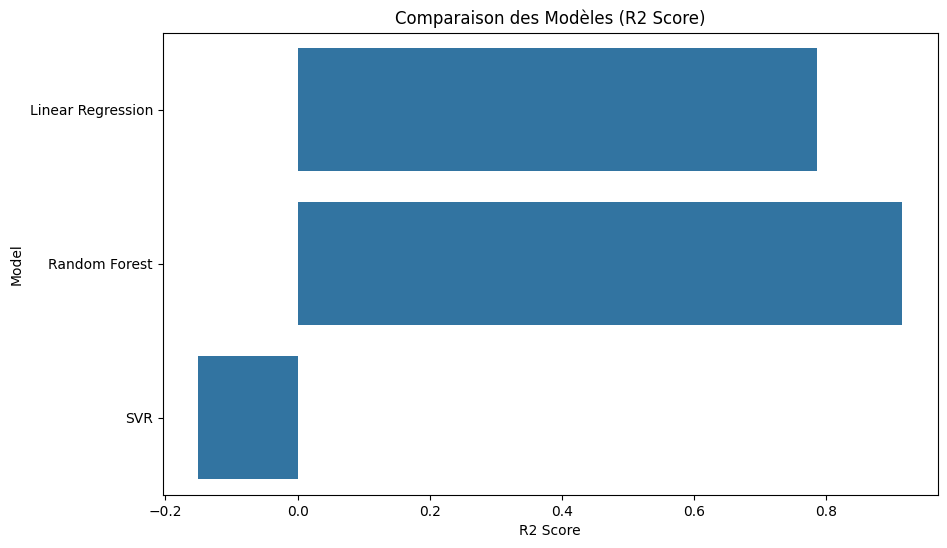

In [12]:
# Initialisation des modèles
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel='rbf')
}

results = []

print("Début de l'entraînement et de l'évaluation...")

for name, model in models.items():
    # Création d'un pipeline complet : Preprocessing -> Modèle
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    
    # Entraînement
    # Attention: SVR peut être long si le dataset dépasse 10-20k lignes. 
    # Si c'est trop lent, on peut réduire le set d'entrainement pour le test : X_train[:5000]
    clf.fit(X_train, y_train)
    
    # Prédiction
    y_pred = clf.predict(X_test)
    
    # Calcul des métriques
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })
    print(f"{name} terminé.")

# Affichage du comparatif
results_df = pd.DataFrame(results)
display(results_df.sort_values(by="R2 Score", ascending=False))

# Visualisation rapide
plt.figure(figsize=(10, 6))
sns.barplot(x="R2 Score", y="Model", data=results_df)
plt.title("Comparaison des Modèles (R2 Score)")
plt.show()

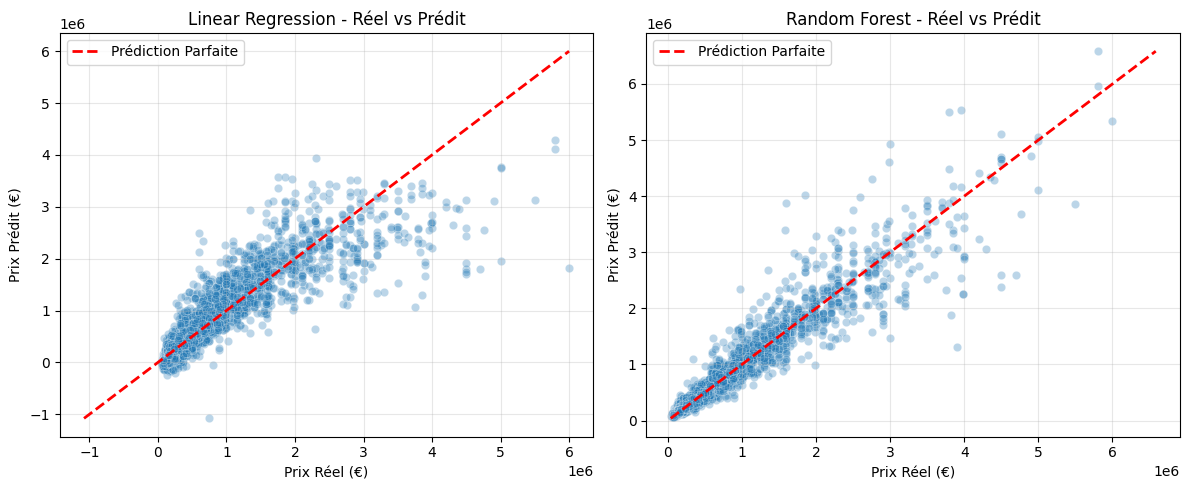

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def evaluer_predictions(models_dict, X_test, y_test):
    """
    Fonction pour visualiser et comparer les prédictions de plusieurs modèles.
    models_dict: Dictionnaire {Nom: Modèle_Entraîné}
    """
    
    # Création d'un DataFrame pour stocker les résultats
    results_df = pd.DataFrame({'Prix Réel': y_test})
    
    # Configuration des graphiques
    n_models = len(models_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1: axes = [axes] # Gérer le cas d'un seul modèle
    
    for i, (name, model) in enumerate(models_dict.items()):
        # 1. Prédiction
        y_pred = model.predict(X_test)
        results_df[f'Pred_{name}'] = y_pred
        results_df[f'Erreur_{name}'] = results_df['Prix Réel'] - y_pred
        
        # 2. Graphique Réel vs Prédit
        ax = axes[i]
        sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, ax=ax)
        
        # Ligne rouge idéale (x=y)
        max_val = max(y_test.max(), y_pred.max())
        min_val = min(y_test.min(), y_pred.min())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prédiction Parfaite')
        
        ax.set_title(f'{name} - Réel vs Prédit')
        ax.set_xlabel('Prix Réel (€)')
        ax.set_ylabel('Prix Prédit (€)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    return results_df

# --- UTILISATION CORRIGÉE ---

# On doit recréer des PIPELINES complets (Préprocessing + Modèle)
# Sinon le modèle reçoit du texte brut et plante.

trained_models = {}

# 1. Pipeline Régression Linéaire
lin_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', LinearRegression())])
lin_reg_pipeline.fit(X_train, y_train)
trained_models["Linear Regression"] = lin_reg_pipeline

# 2. Pipeline Random Forest
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestRegressor(n_estimators=100, random_state=42))])
rf_pipeline.fit(X_train, y_train)
trained_models["Random Forest"] = rf_pipeline

# 3. Pipeline SVR
# svr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
#                                ('classifier', SVR(kernel='rbf'))])
# svr_pipeline.fit(X_train, y_train)
# trained_models["SVR"] = svr_pipeline


# Lancer l'évaluation avec les pipelines complets
df_comparatif = evaluer_predictions(trained_models, X_test, y_test)

AVEC GridSearchCV

In [17]:
# --- BLOC 1 : Linear Regression ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

# 1. Définition de la grille
# La régression linéaire classique a peu d'hyperparamètres.
# On teste si on doit calculer l'intercept (biais) et si les données sont positives (optionnel)
param_grid_lr = {
    'classifier__fit_intercept': [True, False],
    'classifier__positive': [False, True]
}

# 2. Pipeline
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LinearRegression())])

# 3. GridSearchCV
grid_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=5, scoring='r2', n_jobs=-1, verbose=1)

print("Lancement du GridSearch pour Linear Regression...")
grid_lr.fit(X_train, y_train)

print(f"Meilleurs paramètres LR : {grid_lr.best_params_}")
print(f"Meilleur score R2 LR : {grid_lr.best_score_}")

best_lr = grid_lr.best_estimator_

Lancement du GridSearch pour Linear Regression...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Meilleurs paramètres LR : {'classifier__fit_intercept': False, 'classifier__positive': False}
Meilleur score R2 LR : 0.7655597610801311


In [18]:
# --- BLOC 2 : Random Forest ---
from sklearn.ensemble import RandomForestRegressor

# 1. Définition de la grille
# J'ai gardé une grille 'compacte' pour que le temps de calcul reste gérable (24 combinaisons * 3 folds = 72 entrainements)
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

# 2. Pipeline
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestRegressor(random_state=42))])

# 3. GridSearchCV
# cv=3 pour aller plus vite (standard = 5)
grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=3, scoring='r2', n_jobs=-1, verbose=2)

print("Lancement du GridSearch pour Random Forest...")
grid_rf.fit(X_train, y_train)

print(f"Meilleurs paramètres RF : {grid_rf.best_params_}")
print(f"Meilleur score R2 RF : {grid_rf.best_score_}")

best_rf = grid_rf.best_estimator_

Lancement du GridSearch pour Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Meilleurs paramètres RF : {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Meilleur score R2 RF : 0.9062217259761663


In [20]:
# --- BLOC 3 : SVR ---
from sklearn.svm import SVR

# 1. Définition de la grille
# Attention : SVR est très lent sur >10k lignes. Grille très réduite ici.
param_grid_svr = {
    'classifier__C': [1, 10, 100],         # Paramètre de régularisation
    'classifier__epsilon': [0.1, 0.2],     # Marge de tolérance
    'classifier__kernel': ['rbf']          # 'linear' est souvent trop lent ici
}

# 2. Pipeline
svr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', SVR())])

# 3. GridSearchCV
# cv=3 est fortement recommandé ici pour limiter le temps
grid_svr = GridSearchCV(svr_pipeline, param_grid_svr, cv=3, scoring='r2', n_jobs=-1, verbose=2)

print("Lancement du GridSearch pour SVR (Cela peut être long)...")
# Astuce : Si c'est trop long, testez sur une partie des données : 
# grid_svr.fit(X_train[:5000], y_train[:5000])
grid_svr.fit(X_train, y_train)

print(f"Meilleurs paramètres SVR : {grid_svr.best_params_}")
print(f"Meilleur score R2 SVR : {grid_svr.best_score_}")

best_svr = grid_svr.best_estimator_

Lancement du GridSearch pour SVR (Cela peut être long)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Meilleurs paramètres SVR : {'classifier__C': 100, 'classifier__epsilon': 0.1, 'classifier__kernel': 'rbf'}
Meilleur score R2 SVR : -0.05478423786612304


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def extract_metrics_and_params(grid_search_object, model_name, X_test, y_test):
    # 1. Récupération du meilleur modèle
    best_model = grid_search_object.best_estimator_
    
    # 2. Prédictions sur le test set
    y_pred = best_model.predict(X_test)
    
    # 3. Calcul des métriques manquantes
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # 4. Extraction des paramètres spécifiques demandés
    params = grid_search_object.best_params_
    
    # Initialisation des variables avec "N/A" (Non Applicable) par défaut
    fit_intercept = "N/A"
    normalize = "StandardScaler (Pipeline)" # Remplaçant moderne de normalize
    n_estimators = "N/A"
    max_depth = "N/A"
    
    # Extraction conditionnelle selon le modèle
    if "LinearRegression" in model_name:
        fit_intercept = params.get('classifier__fit_intercept', "N/A")
        # Note: normalize n'existe plus en paramètre, c'est le StandardScaler du pipeline qui le fait
        
    elif "RandomForest" in model_name:
        n_estimators = params.get('classifier__n_estimators', "N/A")
        max_depth = params.get('classifier__max_depth', "None") # "None" est une valeur valide ici
        
    # 5. Affichage propre pour copier-coller ou JSON
    print(f"--- {model_name} Résultats ---")
    print(f"RMSE          : {rmse:.2f}")
    print(f"MAE           : {mae:.2f}")
    print(f"R2            : {r2:.4f}")
    print(f"fit_intercept : {fit_intercept}")
    print(f"normalize     : {normalize}")
    print(f"n_estimators  : {n_estimators}")
    print(f"max_depth     : {max_depth}")
    print("-" * 30)
    
    # Retourner un dictionnaire prêt pour le futur JSON
    return {
        "model": model_name,
        "metrics": {"rmse": rmse, "mae": mae, "r2": r2},
        "params": {
            "fit_intercept": fit_intercept,
            "normalize": normalize, 
            "n_estimators": n_estimators,
            "max_depth": max_depth
        }
    }

# --- UTILISATION (A lancer après vos GridSearch) ---

# Pour Linear Regression
data_lr = extract_metrics_and_params(grid_lr, "Linear Regression", X_test, y_test)

# Pour Random Forest
data_rf = extract_metrics_and_params(grid_rf, "Random Forest", X_test, y_test)

# Pour SVR
# data_svr = extract_metrics_and_params(grid_svr, "SVR", X_test, y_test)

--- Linear Regression Résultats ---
RMSE          : 347632.05
MAE           : 194818.98
R2            : 0.7863
fit_intercept : N/A
normalize     : StandardScaler (Pipeline)
n_estimators  : N/A
max_depth     : N/A
------------------------------
--- Random Forest Résultats ---
RMSE          : 218940.01
MAE           : 95158.65
R2            : 0.9152
fit_intercept : N/A
normalize     : StandardScaler (Pipeline)
n_estimators  : N/A
max_depth     : N/A
------------------------------


AVEC RandomizedSearchCV

In [ ]:
# Exemple de Fine-tuning pour Random Forest avec RandomizedSearchCV

# Définition de la grille de paramètres à tester
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

# On reprend le pipeline du Random Forest
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestRegressor(random_state=42))])

# Recherche des meilleurs paramètres
# n_iter=10 limite à 10 combinaisons pour que ça ne soit pas trop long. Augmentez si vous avez du temps.
search = RandomizedSearchCV(rf_pipeline, param_grid, n_iter=10, cv=3, 
                            scoring='r2', n_jobs=-1, verbose=2, random_state=42)

print("Lancement de l'optimisation pour Random Forest...")
search.fit(X_train, y_train)

print(f"Meilleurs paramètres trouvés : {search.best_params_}")
print(f"Meilleur score R2 : {search.best_score_}")

# Sauvegarde du meilleur modèle optimisé dans une variable
best_model = search.best_estimator_